In [26]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

tf.keras.backend.clear_session()

(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

encoder = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu")
])

decoder = Sequential([
    Dense(64, activation="relu", input_shape=(32,)),
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid")
])

input_img = Input(shape=(784,))
encoded = encoder(input_img)
decoded = decoder(encoded)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0461 - val_loss: 0.0250
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0219 - val_loss: 0.0204
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0194 - val_loss: 0.0188
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0181 - val_loss: 0.0176
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0171 - val_loss: 0.0167
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0164 - val_loss: 0.0160
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0157 - val_loss: 0.0156
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0152 - val_loss: 0.0150
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0147 - val_loss: 0.0146
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0143 - val_loss: 0.0145


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


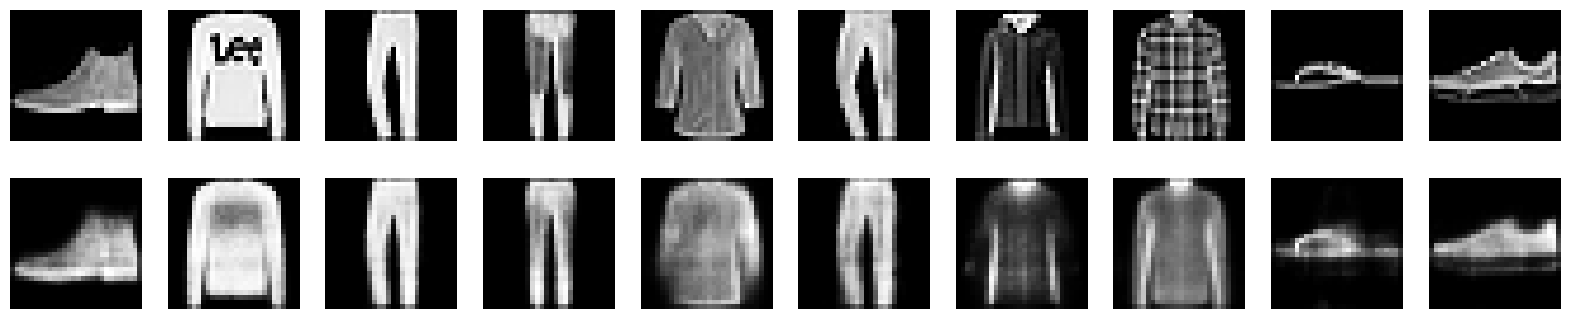

In [28]:
decoded_images = autoencoder.predict(x_test_flat)

import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

In [29]:
autoencoder.save("fashion_mnist_autoencoder.keras")
encoder.save("fashion_mnist_encoder.keras")
decoder.save("fashion_mnist_decoder.keras")